In [1]:
from constants import *
from ml_func import *
from functions import *
from rotation_func import *
from packages import *
from class_sys_info import *

#Current working directory
cwd = os.getcwd()
cwd = cwd[:-9]+'tests/main_test/'
print(f'Start Importing Files from {cwd}')

train_rot = True
train_set = False

MSE_list = []
#Gathering all directories of all molecular systems 
mol_sys_dirs = sorted(os.listdir(cwd))
train_set_fraction = [None]# np.linspace(0.2,0.99,8)
#For every molecular system
for rnd_state in [46]:#,42,0,56,29,100,208,46,30,39]:
    for train in train_set_fraction:
        Systems = []
        mol_sys_idx = []
        for mol in range(len(mol_sys_dirs)):
            #Gathering for each molecular systems all directories of diffrent structures
            mol_dir = f'{cwd}/{mol_sys_dirs[mol]}/'
            struc_sys_dirs = sorted([ name for name in os.listdir(mol_dir) if os.path.isdir(os.path.join(mol_dir, name)) ])
            #print(f'Molecule No. {mol}')
            if mol_sys_dirs[mol] == 'H3':
                test_mol = mol
            #For every structure of every molecular system
            for sys in range(len(struc_sys_dirs)):
                #print(f'System {struc_sys_dirs[sys]}')

                system = sys_info(folder=f'{mol_dir}{struc_sys_dirs[sys]}/init_coord/',molecule=mol,variation=sys)

                system.rot_init_inert()

                system.rot_inert_apf()

                mol_sys_idx.append([mol,sys])

                Systems.append(system)

Start Importing Files from c:\Users\Nutzer\Documents\GitHub\hessian_ml\tests/main_test/


Fitting the Model.
Testing the Model.
1.1845084202400787e-06


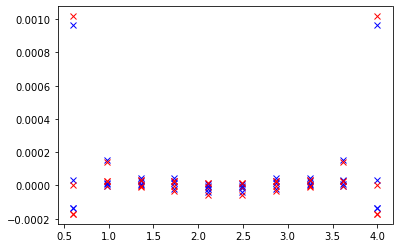

[[ 5.71772210e-03  3.24000000e-08 -2.16000000e-08]
 [ 3.29000000e-08 -6.00308200e-04  1.38385088e-24]
 [-2.20000000e-08  1.27363267e-24 -6.00308200e-04]]
[[ 5.71772210e-03  3.29000000e-08 -2.20000000e-08]
 [ 3.24000000e-08 -6.00308200e-04  1.27363267e-24]
 [-2.16000000e-08  1.38385088e-24 -6.00308200e-04]]
R2(homo)   :0.972
R2(hetero)   :0.949
MSE(homo)  :0.0
MSE(hetero):0.0


In [2]:
        print('Fitting the Model.')
        rnd_state = None

        test_idx = []
        train_idx = []
        for i in range(len(mol_sys_idx)):
            if mol_sys_idx[i][0] == test_mol:
                test_idx.append(i)
            else:
                train_idx.append(i)

        #test_size = 1 - train
        #train_size = train
        #print(f'Train size:{train_size}')
        #train_idx, temp = train_test_split(train_idx,test_size=test_size,train_size=train_size,random_state=rnd_state)
            
        test_train_split_idx = np.arange(0,len(mol_sys_idx),1)
        #train_idx, test_idx = train_test_split(test_train_split_idx,test_size=0.25,train_size=0.75,random_state=rnd_state)

        
        X_homo = []
        y_homo = []

        X_hetero = []
        y_hetero = []

        for i in train_idx:

            Systems[i].gen_Hessian_vector(train_rot=train_rot,train_set =train_set)
            X_homo_temp,X_hetero_temp = Systems[i].gen_Feature(label = 'indexed',train_rot=train_rot,train_set =train_set)

            X_homo.extend(X_homo_temp)
            y_homo.extend(Systems[i].H_AA_vec)

            X_hetero.extend(X_hetero_temp)
            y_hetero.extend(Systems[i].H_AB_vec)

        regr_homonuclear=  ExtraTreesRegressor(n_estimators = 500,random_state=rnd_state,bootstrap=False) 
        regr_heteronuclear = ExtraTreesRegressor(n_estimators = 500,random_state=rnd_state,bootstrap=False)

        #regr_homonuclear = KNeighborsRegressor(n_neighbors=10, weights='distance' )
        #regr_heteronuclear = KNeighborsRegressor(n_neighbors=10, weights='distance' )

        regr_homonuclear.fit(X_homo,y_homo)
        regr_heteronuclear.fit(X_hetero,y_hetero)

        full_y_pred_homo = []
        full_y_pred_hetero = []

        full_X_homo_test = []
        full_X_hetero_test = []

        full_y_test_homo = []
        full_y_test_hetero = []

        test_symmetry_homo = []
        test_symmetry_hetero = []

        print('Testing the Model.')
        lambd = [[],[]]
        test_sys = None

        for i in test_idx:
            X_homo_temp,X_hetero_temp = Systems[i].gen_Feature(label = 'indexed')
            Systems[i].gen_Hessian_vector()

            # if i == test_idx[0]:
            #     print(X_homo_temp[0])
            full_X_homo_test.extend(X_homo_temp)
            full_X_hetero_test.extend(X_hetero_temp)

            full_y_test_homo.extend(Systems[i].H_AA_vec)
            full_y_test_hetero.extend(Systems[i].H_AB_vec)

            y_homo_pred = regr_homonuclear.predict(X_homo_temp)
            y_hetero_pred = regr_heteronuclear.predict(X_hetero_temp)
            #y_hetero_pred

            Systems[i].get_pred_hessian(hessian_homo=y_homo_pred,hessian_hetero=y_hetero_pred)

            full_y_pred_homo.extend(y_homo_pred)
            full_y_pred_hetero.extend(y_hetero_pred)

            test_symmetry_homo.append(np.array(sorted(y_homo_pred)))
            test_symmetry_hetero.append(np.array(sorted(y_hetero_pred)))

            Systems[i].project_hessian(label='xTB')
            Systems[i].project_hessian(label='pred')

            Systems[i].weight_hessian(label='xTB')
            Systems[i].weight_hessian(label='pred')

            Systems[i].gen_eigenvalues()
            lambd[0].append(sorted(Systems[i].hessian_lambd))
            lambd[1].append(sorted(Systems[i].H_pred_lambd))

        length = np.linspace(0.6,4,10)
        for i in range(len(length)):
            for j in range(4):
                plt.plot(length[i],lambd[1][i][j],'bx')
                plt.plot(length[i],lambd[0][i][j],'rx')
        
        MSE = 0 
        for i in range(5):
            for j in range(4):
                MSE += 1/(5*4) * np.abs(lambd[1][i][j] - lambd[1][-(1+i)][j])

        print(MSE)
        MSE_list.append(MSE)
        plt.show()
        #eigh_H_pred3 = Systems[test_idx[3]].H_pred_lambd
        #eigh_H_pred6 = Systems[test_idx[6]].H_pred_lambd

        #Systems[test_idx[3]].perm_Hess(0,2)
        #Systems[test_idx[3]].gen_eigenvalues()
        #eigh_H_pred_perm3 = Systems[test_idx[3]].H_pred_lambd

        #Systems[test_idx[6]].perm_Hess(0,2)
        #Systems[test_idx[6]].gen_eigenvalues()
        #eigh_H_pred_perm6 = Systems[test_idx[6]].H_pred_lambd

        #print(eigh_H_pred3)
        #print(eigh_H_pred_perm3)

        #print(eigh_H_pred6)
        #print(eigh_H_pred_perm6)
        #print(Systems[test_idx[3]].xyz)
        #print(Systems[test_idx[6]].xyz)

        #Systems[test_idx[1]].rot_init_inert()
        #Systems[test_idx[8]].rot_init_inert()
        #print(Systems[test_idx[3]].features.Feature_AA[0:1])

        #print(regr_homonuclear.predict(Systems[test_idx[3]].features.Feature_AA[0:1]))  
        #print(regr_homonuclear.predict(Systems[test_idx[6]].features.Feature_AA[18:19]))
        mat2 = np.array(Systems[test_idx[2]].H_APF_mat)[3:6,6:9]
        R2 = np.array(Systems[test_idx[2]].R_MI_APF_mat)[3:6,6:9]

        mat7 = np.array(Systems[test_idx[7]].H_APF_mat)[0:3,3:6]
        R7 = np.array(Systems[test_idx[7]].R_MI_APF_mat)[0:3,3:6]

        c2 = matmul(matmul((R2),mat2),np.transpose(R2))
        c7 = matmul(matmul((R7),mat7),np.transpose(R7))

        print(c2)
        print(c7)

        #mat2 = np.array(Systems[test_idx[7]].H_APF_mat)
     
        #Systems[test_idx[2]].perm_Hess(0,2)
        #Systems[test_idx[7]].perm_Hess(0,2)
        mat1 = np.array(Systems[test_idx[2]].hessian)
        mat2 = np.array(Systems[test_idx[7]].hessian)
        mat3 = np.array(Systems[test_idx[2]].H_APF_mat)
        mat4 = np.array(Systems[test_idx[7]].H_APF_mat)
        mat22 = np.zeros([9,9])
        mat44 = np.zeros([9,9])

        # for i in range(0,7,3):
        #     for j in range(0,7,3):          
        #         R = rot_Z(0)
        #         mat44[(6-i):(6-i)+3,(6-j):(6-j)+3] = matmul(matmul((R),mat4[i:i+3,j:j+3]),np.transpose(R))
        #         mat22[(6-i):(6-i)+3,(6-j):(6-j)+3] = matmul(matmul((R),mat2[i:i+3,j:j+3]),np.transpose(R))
        
        '''fig,axs = plt.subplots(2,2)
        vminmax = 1e-6

        axs[0,0].imshow(mat1, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        axs[0,0].set_title('H123 GFN2 calc.')
        axs[0,1].imshow(mat2, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        axs[0,1].set_title('adj. H321 GFN2 calc.')
        axs[1,0].imshow(mat3, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        axs[1,0].set_title('H123 ML pred.')
        axs[1,1].imshow(mat4, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        axs[1,1].set_title('adj. H321 ML pred.')'''
        #axs[0,2].imshow(mat1-mat22, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        #axs[0,2].set_title('Difference GFN2')
        #axs[1,2].imshow(mat3-mat44, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        #axs[1,2].set_title('Difference ML pred.')

        #print(Systems[test_idx[1]].features.qm_atom[:])
        #print(Systems[test_idx[8]].features.qm_atom[:])
        #print(Systems[test_idx[2]].R_MI_APF_mat-Systems[test_idx[7]].R_MI_APF_mat)



        r_score_homo = regr_homonuclear.score(full_X_homo_test,full_y_test_homo)
        r_score_hetero = regr_heteronuclear.score(full_X_hetero_test,full_y_test_hetero)

        MSE_homonuclear  = mean_squared_error(full_y_test_homo,full_y_pred_homo)
        MSE_heteronuclear  = mean_squared_error(full_y_test_hetero,full_y_pred_hetero)

        print(f'R2(homo)   :{round(r_score_homo,3)}')
        print(f'R2(hetero)   :{round(r_score_hetero,3)}')

        print(f'MSE(homo)  :{round(MSE_homonuclear,3)}')
        print(f'MSE(hetero):{round(MSE_heteronuclear,3)}')
        '''

        #plt.xlabel(r'$x$(H2) [$\mathrm{\AA}$]',fontsize=24)
        #plt.ylabel(r'$k~[\mathrm{N~\mathrm{m}^{-1}}]$',fontsize=24)  
        '''

        #plt.savefig(f'plots/lambda_symmetry_check{time_atm}.png')
        #plt.savefig(f'plots/lambda_symmetry_check{time_atm}.svg')

        plt.show()

np.savetxt('MSE_list.txt',MSE_list)

In [5]:
#for i in [2,7]:
#    for j in range(0,9,3):
#        print(Systems[test_idx[i]].H_APF_mat[j:j+3,j:j+3])

#print(Systems[test_idx[0]].hessian[0:3,3:6])
#print(Systems[test_idx[9]].xyz)
# fig, ax = plt.subplots(1,3)

# ax[0].imshow(Systems[test_idx[0]].H_pred)
# ax[1].imshow(Systems[test_idx[9]].H_pred)
# ax[2].imshow(Systems[test_idx[0]].H_pred - Systems[test_idx[9]].H_pred)



#Systems[test_idx[9]].perm_Hess(0,2)

test = True
for i in [9]:
    for k in range(168):
        if round(Systems[test_idx[0]].features.Feature_AB[i][k],5) != round(Systems[test_idx[9]].features.Feature_AB[i][k],5):
            # print(Systems[test_idx[0]].features.Feature_AB[i][k])
            # # #print(Systems[test_idx[0]].H_AB_vec[i])
            # print(Systems[test_idx[9]].features.Feature_AB[i][k])
            # print(k)
            # #print(Systems[test_idx[9]].H_AB_vec[18+i])
            test = False

print((Systems[test_idx[9]].features.transpose_list))

for i in [0]:
    print(Systems[test_idx[9]].features.Feature_AB[9][33])
    print(Systems[test_idx[9]].features.CN)



[[0, 1], [1, 2], [1, 2]]
0.9988432
[[9.6600000e-06 9.6500000e-06]
 [9.9884320e-01 9.9767869e-01]
 [9.9884038e-01 9.9768151e-01]]


0 0
1 0
2 1
0 1
1 0
2 1
0 2
1 0
2 1


[[-1.57222080e-01  5.71920000e-06  7.00399997e-22]
 [ 5.71920000e-06  9.35080699e-01  3.81280000e-06]
 [ 7.00399997e-22  3.81280000e-06 -1.57222080e-01]]


Text(0.5, 1.0, 'adj. H321 ML pred.')

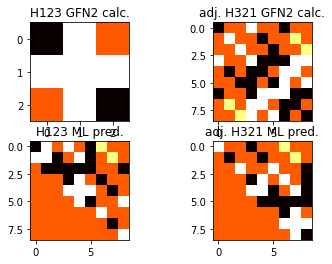

In [17]:
mat1 = np.array(Systems[test_idx[0]].hessian)
mat2 = np.array(Systems[test_idx[9]].hessian)
mat3 = np.array(Systems[test_idx[0]].H_APF_mat)
mat4 = np.array(Systems[test_idx[9]].H_APF_mat)
mat22 = np.zeros([9,9])
mat44 = np.zeros([9,9])

# for i in range(0,7,3):
#     for j in range(0,7,3):          
#         R = rot_Z(0)
#         mat44[(6-i):(6-i)+3,(6-j):(6-j)+3] = matmul(matmul((R),mat4[i:i+3,j:j+3]),np.transpose(R))
#         mat22[(6-i):(6-i)+3,(6-j):(6-j)+3] = matmul(matmul((R),mat2[i:i+3,j:j+3]),np.transpose(R))

fig,axs = plt.subplots(2,2)
vminmax = 1e-6

axs[0,0].imshow(mat1, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
axs[0,0].set_title('H123 GFN2 calc.')
axs[0,1].imshow(mat2, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
axs[0,1].set_title('adj. H321 GFN2 calc.')
axs[1,0].imshow(mat3, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
axs[1,0].set_title('H123 ML pred.')
axs[1,1].imshow(mat4, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
axs[1,1].set_title('adj. H321 ML pred.')